1. Import libraries
        ↓
2. Load dataset
        ↓
3. Inspect dataset
        ↓
4. Check missing values
        ↓
5. Check duplicates
        ↓
6. Descriptive statistics
        ↓
7. Quality-score distribution
        ↓
8. EDA
        ↓
9. Class imbalance
        ↓
10. Create quality categories
        ↓
11. Prepare X and y
        ↓
12. Train-test split
        ↓
13. Random Forest
        ↓
14. SGD
        ↓
15. SVC
        ↓
16. Evaluation
        ↓
17. Feature importance
        ↓
18. Model comparison
        ↓
19. Conclusion

# Wine Quality Prediction Using Machine Learning

### Objective
To train and compare multiple classification models to predict wine quality categories based on their physicochemical properties.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [9]:
Wine_Quality_Dataset = pd.read_csv("Wine_Quality_Dataset.csv")

In [10]:
Wine_Quality_Dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
Wine_Quality_Dataset.shape

(1599, 12)

In [12]:
Wine_Quality_Dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [13]:
Wine_Quality_Dataset.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [14]:
Wine_Quality_Dataset.duplicated().sum()

np.int64(240)

In [15]:
Wine_Quality_Dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [16]:
Wine_Quality_Dataset["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

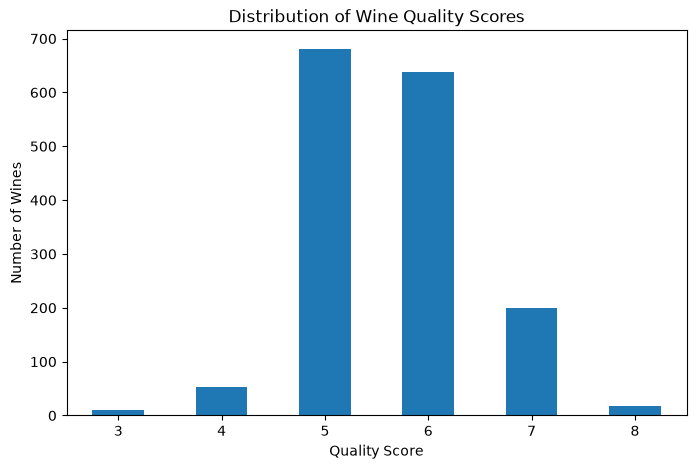

In [17]:
Wine_Quality_Dataset["quality"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.xticks(rotation=0)
plt.show()

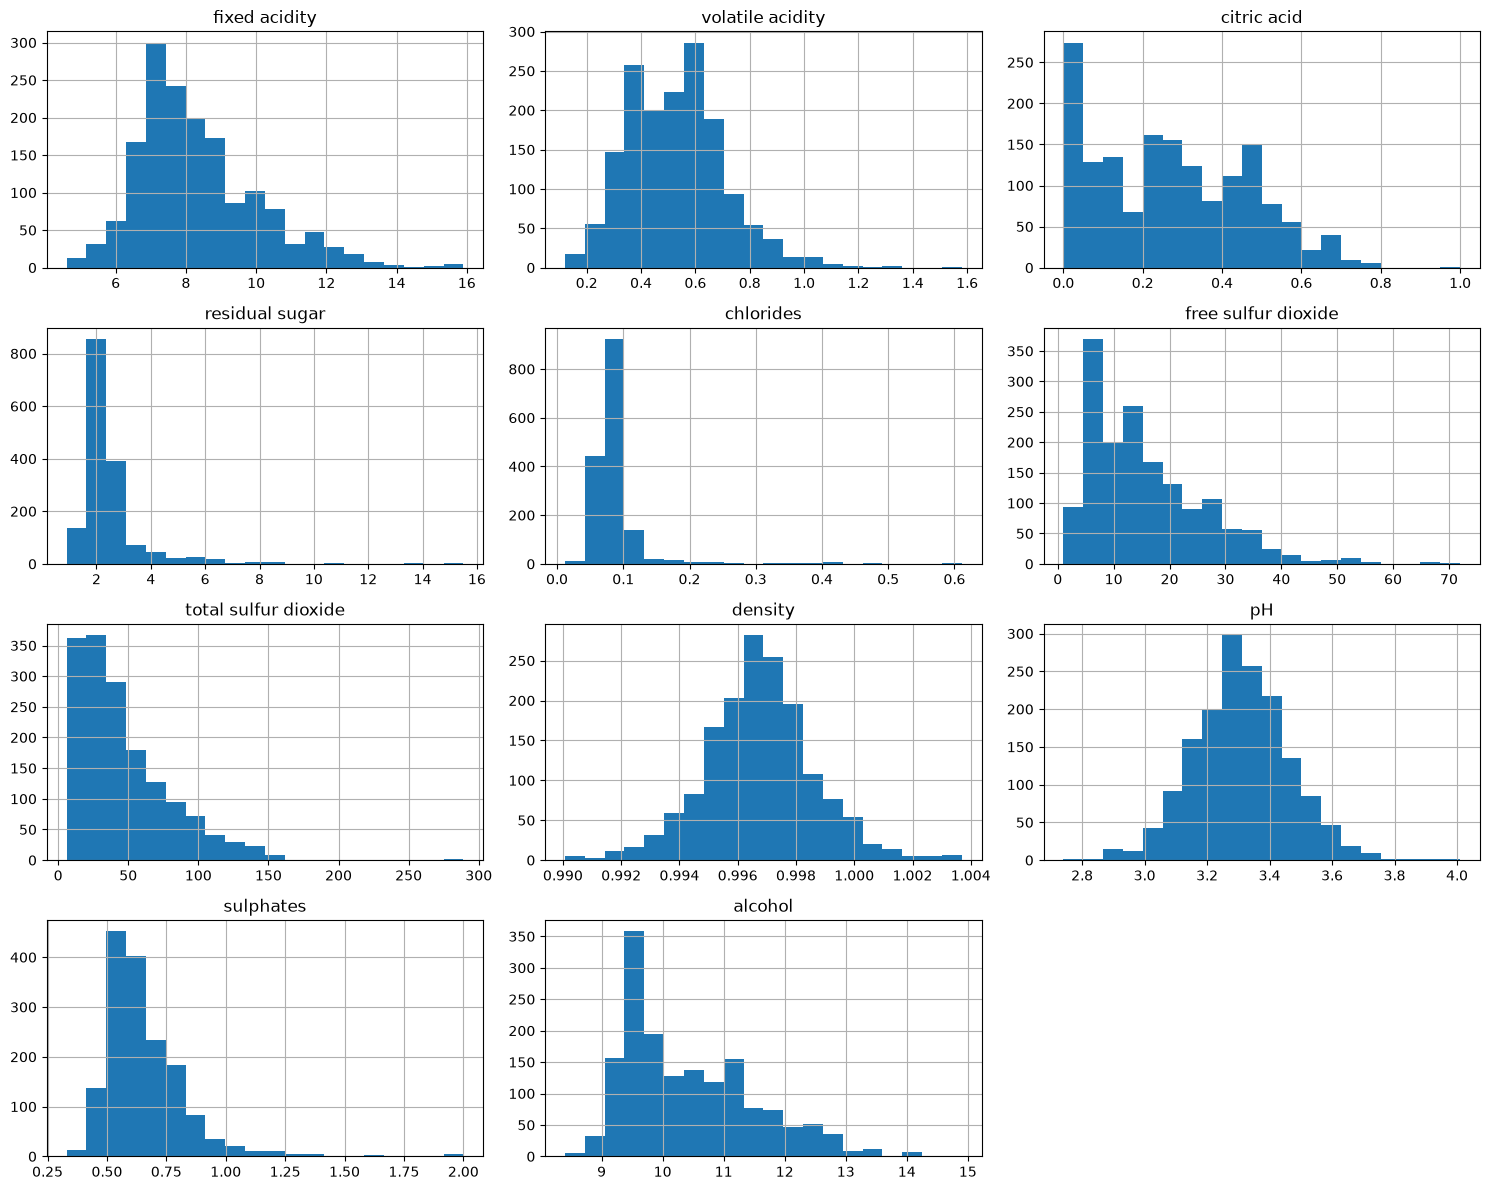

In [19]:
features = Wine_Quality_Dataset.drop(columns=["quality"])

features.hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

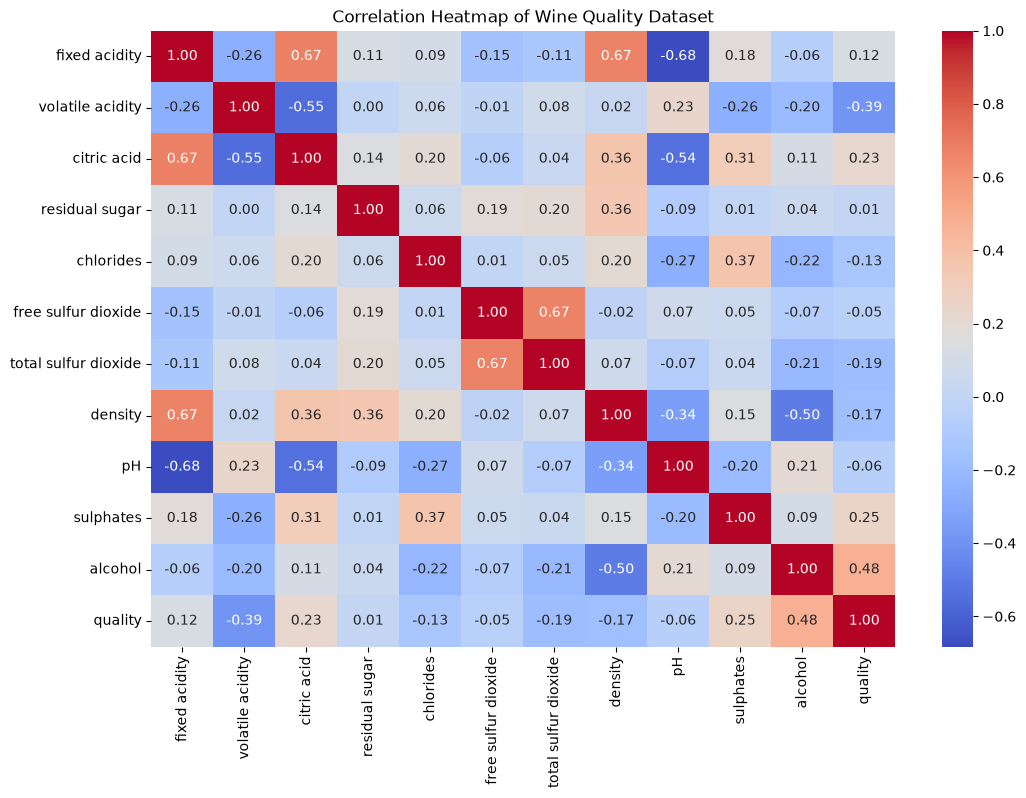

In [20]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    Wine_Quality_Dataset.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Wine Quality Dataset")
plt.show()

In [21]:
def quality_category(quality):
    if quality <= 4:
        return "Low"
    elif quality <= 6:
        return "Medium"
    else:
        return "High"


Wine_Quality_Dataset["quality_category"] = Wine_Quality_Dataset["quality"].apply(
    quality_category
)

In [22]:
Wine_Quality_Dataset["quality_category"].value_counts()

quality_category
Medium    1319
High       217
Low         63
Name: count, dtype: int64

In [23]:
X = Wine_Quality_Dataset.drop(columns=["quality", "quality_category"])
y = Wine_Quality_Dataset["quality_category"]

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1599, 11)
y shape: (1599,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1279, 11)
X_test: (320, 11)
y_train: (1279,)
y_test: (320,)


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1279, 11)
X_test_scaled shape: (320, 11)


In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [32]:
rf_pred = rf_model.predict(X_test)

In [33]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.865625

Classification Report:
              precision    recall  f1-score   support

        High       0.71      0.51      0.59        43
         Low       0.00      0.00      0.00        13
      Medium       0.88      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.49      0.51       320
weighted avg       0.82      0.87      0.84       320



C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

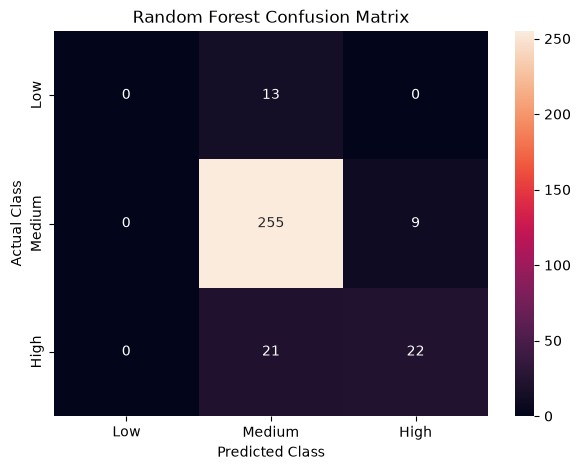

In [35]:
class_order = ["Low", "Medium", "High"]

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=class_order
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [36]:
sgd_model = SGDClassifier(
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [37]:
sgd_pred = sgd_model.predict(X_test_scaled)

In [38]:
print("SGD Accuracy:", accuracy_score(y_test, sgd_pred))

print("\nClassification Report:")
print(classification_report(y_test, sgd_pred))

SGD Accuracy: 0.825

Classification Report:
              precision    recall  f1-score   support

        High       0.52      0.33      0.40        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.95      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.42      0.43       320
weighted avg       0.78      0.82      0.80       320



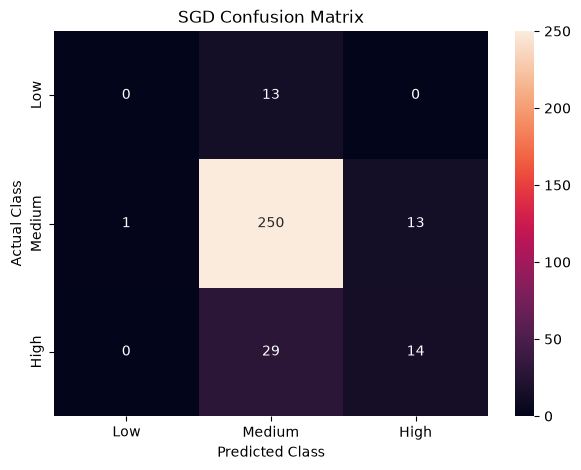

In [39]:
class_order = ["Low", "Medium", "High"]

cm_sgd = confusion_matrix(
    y_test,
    sgd_pred,
    labels=class_order
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt="d",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [40]:
svc_model = SVC(
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [41]:
svc_pred = svc_model.predict(X_test_scaled)

In [42]:
print("SVC Accuracy:", accuracy_score(y_test, svc_pred))

print("\nClassification Report:")
print(classification_report(y_test, svc_pred))

SVC Accuracy: 0.84375

Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.33      0.43        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.97      0.91       264

    accuracy                           0.84       320
   macro avg       0.50      0.43      0.45       320
weighted avg       0.79      0.84      0.81       320



C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

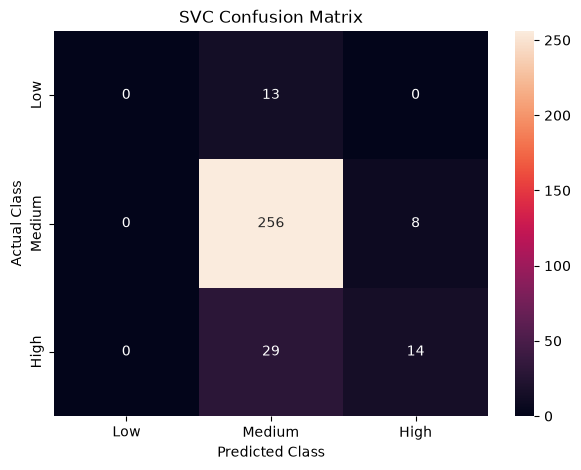

In [43]:
class_order = ["Low", "Medium", "High"]

cm_svc = confusion_matrix(
    y_test,
    svc_pred,
    labels=class_order
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.146866
1,volatile acidity,0.130046
9,sulphates,0.104467
7,density,0.092413
2,citric acid,0.085064
0,fixed acidity,0.083301
6,total sulfur dioxide,0.080194
3,residual sugar,0.073206
4,chlorides,0.071864
8,pH,0.067959


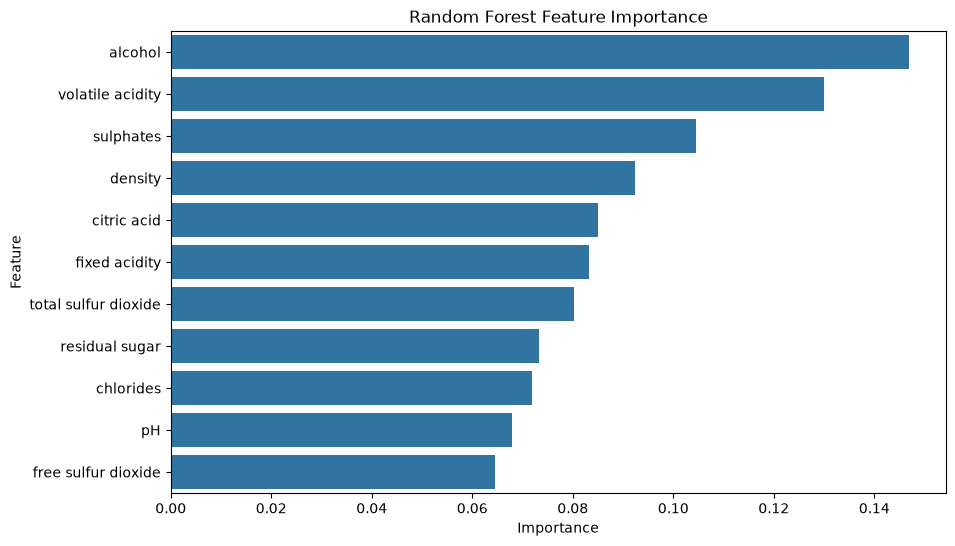

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred, average="macro"),
        precision_score(y_test, sgd_pred, average="macro"),
        precision_score(y_test, svc_pred, average="macro")
    ],
    "Recall": [
        recall_score(y_test, rf_pred, average="macro"),
        recall_score(y_test, sgd_pred, average="macro"),
        recall_score(y_test, svc_pred, average="macro")
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, sgd_pred, average="macro"),
        f1_score(y_test, svc_pred, average="macro")
    ]
})

model_comparison

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.865625,0.530677,0.492512,0.505612
1,SGD,0.825000,0.458228,0.424184,0.433094
2,SVC,0.843750,0.498475,0.431759,0.447267


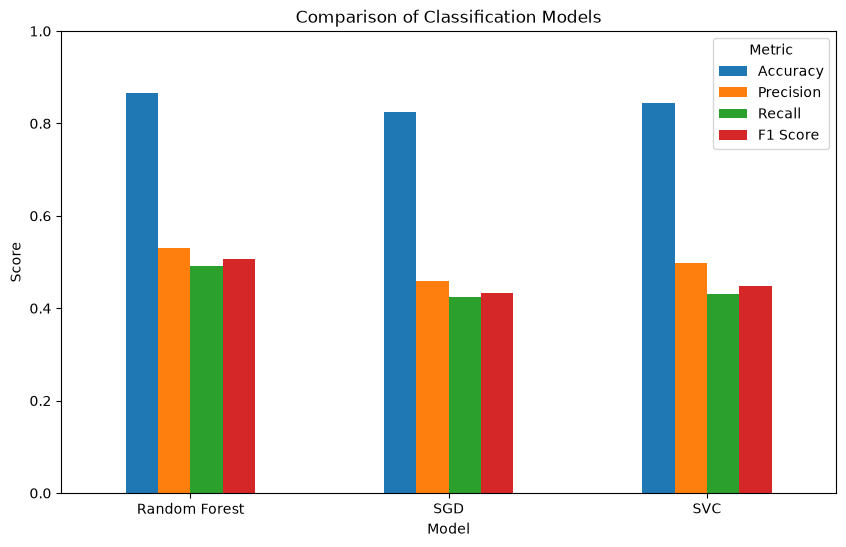

In [47]:
model_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

In [48]:
print("Random Forest")
print(classification_report(y_test, rf_pred))

print("\nSGD")
print(classification_report(y_test, sgd_pred))

print("\nSVC")
print(classification_report(y_test, svc_pred))

Random Forest
              precision    recall  f1-score   support

        High       0.71      0.51      0.59        43
         Low       0.00      0.00      0.00        13
      Medium       0.88      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.49      0.51       320
weighted avg       0.82      0.87      0.84       320


SGD
              precision    recall  f1-score   support

        High       0.52      0.33      0.40        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.95      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.42      0.43       320
weighted avg       0.78      0.82      0.80       320


SVC
              precision    recall  f1-score   support

        High       0.64      0.33      0.43        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.97      0.91       2

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

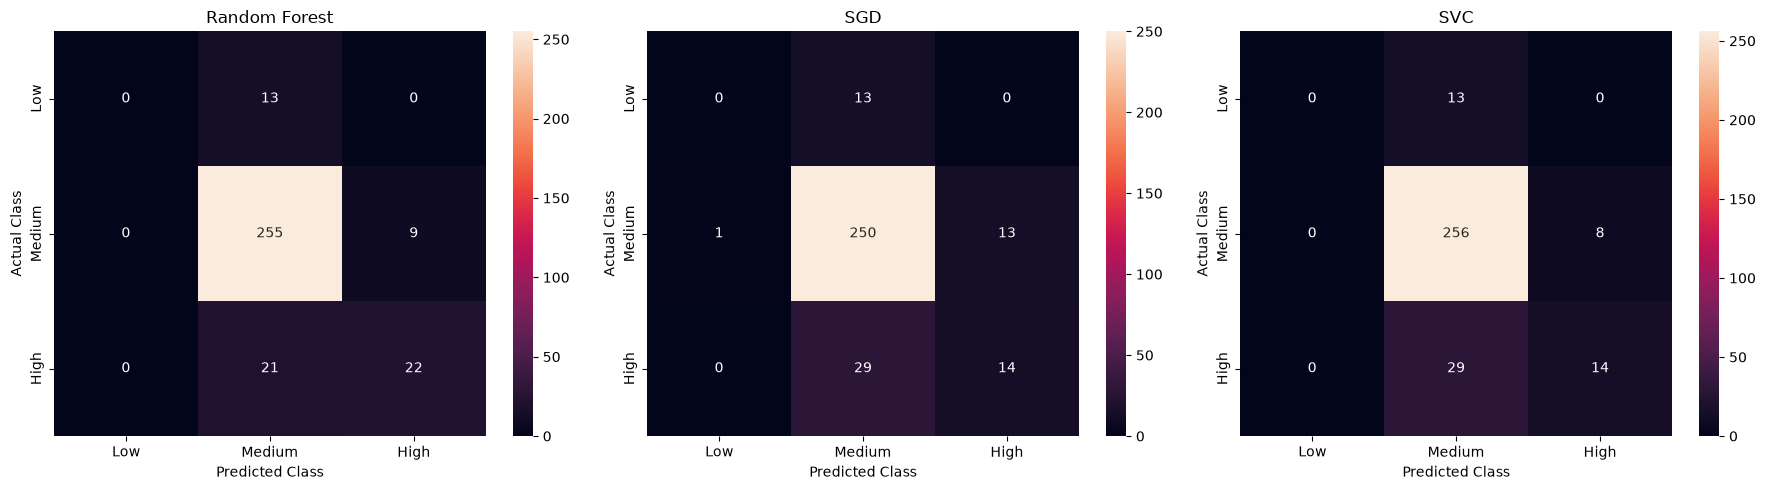

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Random Forest", rf_pred),
    ("SGD", sgd_pred),
    ("SVC", svc_pred)
]

for ax, (name, predictions) in zip(axes, models):
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=["Low", "Medium", "High"]
    )
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax,
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [50]:
model_comparison.to_csv("model_comparison.csv", index=False)

Conclusion

This project developed and evaluated machine learning classification models for predicting wine quality using physicochemical properties of wine. The original quality scores were grouped into three categories: Low (quality scores 3-4), Medium (5-6), and High (7-8). Exploratory data analysis showed that the dataset was highly imbalanced, with Medium-quality wines accounting for the majority of observations.

Three classification algorithms - Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC) - were trained and evaluated using accuracy, precision, recall, F1-score, and confusion matrices. Among the three models, Random Forest achieved the best overall performance, with an accuracy of 86.56% and a macro F1-score of 50.56%. SVC achieved an accuracy of 84.38%, while SGD achieved 82.50%.

The Random Forest model performed particularly well in predicting Medium-quality wines, achieving an F1-score of 0.92, and performed better than the other models in identifying High-quality wines, with an F1-score of 0.59. However, all three models struggled to identify Low-quality wines, recording an F1-score of 0.00 for this class. This limitation is largely associated with the severe class imbalance in the dataset.

Overall, Random Forest is the recommended model among the three tested models because it produced the strongest overall performance. However, further improvement is recommended before deployment, particularly through techniques for addressing class imbalance and improving the detection of minority classes.

Limitations

1. Class imbalance: The dataset was highly imbalanced, with Medium-quality wines making up most of the observations, while Low-quality wines were very few. This affected the ability of the models to correctly identify the minority class.
2. Limited dataset size: The dataset contained 1,599 observations, which may limit the model’s ability to generalize to a larger and more diverse population of wines.
3. Poor prediction of Low-quality wines: All three models recorded an F1-score of 0.00 for the Low-quality class. This indicates that the models had difficulty identifying wines in this category.
4. Limited number of models: Only Random Forest, SGD, and SVC were evaluated. Other machine-learning algorithms may produce different or improved results.
5. No external validation: The models were evaluated using a single train-test split. Testing the models on an independent dataset could provide stronger evidence of their generalizability.

Recommendations

1. Address class imbalance: Future studies should use techniques such as class weighting, oversampling, or SMOTE to improve the prediction of minority classes, particularly Low-quality wines.
2. Collect more data: Additional wine-quality observations should be collected to provide more representative data for training the models.
3. Test additional machine-learning algorithms: Other algorithms, such as Gradient Boosting, XGBoost, or Logistic Regression, could be tested and compared with the models used in this study.
4. Use cross-validation: K-fold cross-validation should be used in future work to provide a more reliable estimate of model performance.
5. Improve model tuning: Hyperparameter tuning could be applied to the models, especially the Random Forest model, to determine whether better performance can be achieved.
6. Use additional evaluation metrics: Because of the class imbalance, future studies should place greater emphasis on macro F1-score, precision, recall, and confusion matrices rather than accuracy alone.

Overall Recommendation

Based on the results of this study, Random Forest is recommended as the best-performing model among the three models tested. However, the model should first be improved by addressing class imbalance, particularly the poor prediction of Low-quality wines, before being considered for real-world deployment.